In [2]:
pip install -U -q "langchain[google-genai]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.4/236.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.2/121.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.8/68.8 kB 4.7 MB/s eta 0:00:00


In [5]:
from langgraph.graph import StateGraph, END,START
from typing import TypedDict
from pydantic import BaseModel, Field

In [1]:
def print_workflow_info(workflow, app=None):
    """Prints comprehensive information about a LangGraph workflow."""
    print("WORKFLOW INFORMATION")
    print("====================")
    print(f"Nodes: {workflow.nodes}")
    print(f"Edges: {workflow.edges}")


    # Use getter method for finish points if available
    try:
        finish_points = workflow.finish_points
        print(f"Finish points: {finish_points}")
    except:
        try:
            # Alternative approaches
            print(f"Finish point: {workflow._finish_point}")
        except:
            print("Finish points attribute not directly accessible")

    if app:
        print("\nWorkflow Visualization:")
        from IPython.display import display
        display(app.get_graph().draw_png())

In [3]:
import os
from langchain.chat_models import init_chat_model
from google.colab import userdata

os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")

model = init_chat_model(
    model="gemini-2.5-flash",
    model_provider="google_genai"
)

### Workflow Pattern: Routing

Routing is a pattern where an LLM (or small router agent) **classifies or interprets incoming input** and then **routes it to the appropriate sub-process** or agent. This design is helpful when you're dealing with **multiple types of tasks or user intents**, and you want specialized logic or handling for each case.

It works like a switchboard — one intelligent node (a classifier or router) analyzes the input and directs it to the correct branch.

#### Use Cases:
- AI customer service bots (route billing, tech support, or general inquiries)
- Multi-skill agents (for example, summarization, translation, and data extraction)
- Adaptive education bots (route to math, science, or grammar modules)

---

#### Routing Techniques:
1. **Hard-coded keyword-based routing** (primitive)
2. **LLM-based routing** using classification prompts
3. **Embedding-based semantic matching** with a routing map

---


### Use Case: Routing — Task Classifier for Summarization and Translation

In this workflow, we are going to build a simple **task router** using the Routing design pattern. The goal is to create a system that can intelligently decide whether the user wants to **summarize** or **translate** a given input, and then send it to the appropriate processing path.

This pattern is useful when the system needs to handle **multiple types of tasks** based on the user’s intent. Instead of creating one large model to handle everything, we let a **router node** classify the request and direct it to a **specialized sub-process**.

For example:
- If the input is “Summarize this article about AI,” the router sends it to the **summarizer**.
- If the input is “Translate this to French,” it sends it to the **translator**.


In [24]:
class RouterState(TypedDict):
    user_input: str
    task_type: str
    output: str

In [26]:
class Router(BaseModel):
    role: str = Field(..., description="Decide whether the user wants to summarize a passage  ouput 'summarize'  or translate text into French oupput translate.")
llm_router=model.bind_tools([Router])

In [27]:
response=llm_router.invoke("summarize this I love the sun its so warm")

In [28]:
def router_node(state: RouterState) -> RouterState:
    routing_prompt = f"""
    You are an AI task classifier.

    Decide whether the user wants to:
    - "summarize" a passage
    - or "translate" text into French

    Respond with just one word: 'summarize' or 'translate'.

    User Input: "{state['user_input']}"
    """

    response = llm_router.invoke(routing_prompt)

    return {**state, "task_type": response.tool_calls[0]['args']['role']} # This becomes the next node's name!

Now we are defining the `router` function, which simply returns the `task_type` from the state. This value will be used by LangGraph to decide which node to route to next based on the classification result.


In [29]:
def router(state: RouterState) -> str:
    return state['task_type']

In [30]:
def summarize_node(state: RouterState) -> RouterState:
    prompt = f"Please summarize the following passage:\n\n{state['user_input']}"
    response = model.invoke(prompt)

    return {**state, "task_type": "summarize", "output": response.content}

In [31]:
def translate_node(state: RouterState) -> RouterState:
    prompt = f"Translate the following text to French:\n\n{state['user_input']}"
    response = model.invoke(prompt)

    return {**state, "task_type": "translate", "output": response.content}

In [32]:
workflow = StateGraph(RouterState)


In [33]:
workflow.add_node("router", router_node)
workflow.add_node("summarize", summarize_node)
workflow.add_node("translate", translate_node)

In [34]:
workflow.set_entry_point("router")

In [35]:
workflow.add_conditional_edges("router", router, {
    "summarize": "summarize",
    "translate": "translate"
})

In [36]:
workflow.set_finish_point("summarize")
workflow.set_finish_point("translate")

In [37]:
app = workflow.compile()


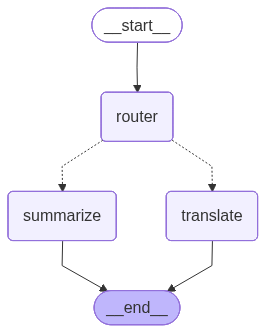

In [38]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [39]:
input_text = {
        "user_input": "Can you translate this sentence: I love programming?"
    }

result = app.invoke(input_text)

In [40]:
print(result[ 'output'])
print(result['task_type'])

J'aime la programmation.
translate


In [41]:
input_text = {
        "user_input": "Can you summarize this sentence: I love programming so much it is the best thing ever. All I want to do is programming?"
    }

result = app.invoke(input_text)

In [42]:
print(result[ 'output'])
print(result['task_type'])

The speaker expresses an intense passion for programming, considering it the best thing and their sole desire.
summarize
